# Rapport de Projet : Open The Chests

**Groupe :**  
Damien LEGRAND,  
Marie DIDIER,  
Alexandre LAPRERIE,  
Thomas TEIXEIRA

**Cours :**  
CSC_5IA10_TA — Multi-Agent Games in Control  

## Introduction

Ce projet combine logique temporelle et contrôle robotique autour du problème *Open The Chests*. Un agent doit apprendre à reconnaître une séquence d'événements (couleurs de coffres) et à piloter un bras robotique KUKA pour ouvrir le bon coffre dans le bon ordre.

## Objectifs

- **Task 1 :** Maîtrise du bras KUKA — entraîner un agent RL à déplacer le bras vers une cible colorée.
- **Task 2 :** Reconnaissance de séquences d'événements — apprendre à identifier l'ordre correct des couleurs.
- **Task 3 :** Intégration *End-to-End* — combiner les deux modèles dans un pipeline complet.

---

## Tâche 1 : Contrôle du Bras Robotique (KUKA)

Dans cette première phase, nous abordons le problème du contrôle moteur d'un bras articulé au sein d'un moteur de physique PyBullet. L'objectif est d'entraîner un agent à atteindre un coffre cible parmi trois, en se basant sur des observations continues.  

### Formalisation de l'Environnement

Le problème est modélisé comme un Processus de Décision Markovien (MDP) défini par le triplet $(\mathcal{S}, \mathcal{A}, \mathcal{R})$ :
- Espace des États $\mathcal{S}$ : Le vecteur d'observation est de dimension 10. Il inclut les coordonnées de l'effecteur, les positions relatives des coffres, et un encodage one-hot de la couleur cible. 
- Espace des Actions $\mathcal{A}$ : L'action est continue et de dimension 3. Elle correspond aux déplacements incrémentaux $\Delta x, \Delta y, \Delta z$ de l'effecteur dans l'espace de travail.
- Fonction de Récompense ($\mathcal{R}$) : La récompense est hybride. Elle combine la distance euclidienne négative par rapport à la cible pour guider l'exploration le bonus de succès lors de la collision avec le coffre correct.


## Entrainement 

Pour résoudre cette tâche, nous avons utilisé l'algorithme PPO. L'architecture du réseau de neurones utilisée est une MlpPolicy composée de deux couches cachées de 64 neurones chacune. L'entraînement a été réalisé sur un horizon de 3 000 000 pas de temps pour garantir la convergence de la politique. Cet entrainement a été effectué sur le Cluster ENSTA pour gagner du temps. Voici ci-dessous la learning curve associé à cet entrainement.

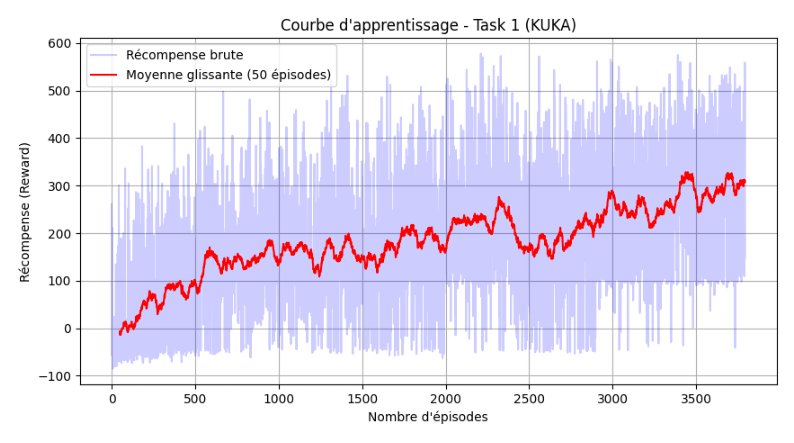

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_1/learning_curve.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

On se rends compte que le reward moyen glissant au fil des epochs augmente, ce qui confirme que l'entrainement est effectué. A l'issu de cet entrainement, on obtient cependant un taux de réussite de 5 %. Voici un l'extrait d'une epoch avec ce modèle entrainé : 

In [ ]:
from IPython.display import Video
Video("assets_task_1/video_after_training.mp4", embed=True)



Le robot semble se rapprocher très vite de la boite, puis s'arréter devant avant de le toucher. On suppose que ceci est dû à la fonction qui est utilisé pour calculer les récompenses, qui donne un bonus au robot quand il ets proche de la boite. Ainsi, le robot préfère rester proche de la boite pour récupérer des récompenses, sans la touche car sinon, celle-ci s'arrêterait.

Pour essayer d'obtenir de meilleurs performances, essayons de modifier la fonction de reward pour la rendre plus pertinente et plus précise. Nous allons implémenter la fonction de reward suivante : 

$$R_t = -1.0 \cdot \|d_t\| + 2.0 \cdot e^{-5.0 \|d_t\|} - 0.1 \cdot \Delta t + \mathbb{1}_{success} \cdot 1000.0$$
Cette nouvelle formulation repose sur trois piliers correctifs par rapport à la fonction par défaut :
- Le guidage exponentiel ($2.0 \cdot e^{-5.0 \|d_t\|}$) : Il a pour but de créer un puit de potentiel autour du coffre. Plus l'effecteur s'approche de la cible, plus le signal de récompense augmente de manière non linéaire, forçant l'agent à affiner sa précision terminale.
- La pénalité de temps ($-0.1 \cdot \Delta t$) : L'introduction d'un coût fixe de 0.1 à chaque pas de temps incite l'agent à minimiser la durée de l'épisode. Cela élimine les trajectoires hésitantes ou circulaires et favorise une planification de mouvement plus directe et efficiente.
- Un bonus élevé quand le robot gagne la partie pour ne pas qu'il se stabilise autout pour gagner des points sans interrompre la partie.

Cependant, même malgré cette nouvelle reward function, nous ne parvenons pas à obtenir de bon résultat. Ici, le taux de réussite est approximativement de 40% pour un entrainement sur 400 000 epochs, ce qui reste plutôt mauvais. Voici la learning curve associé : 

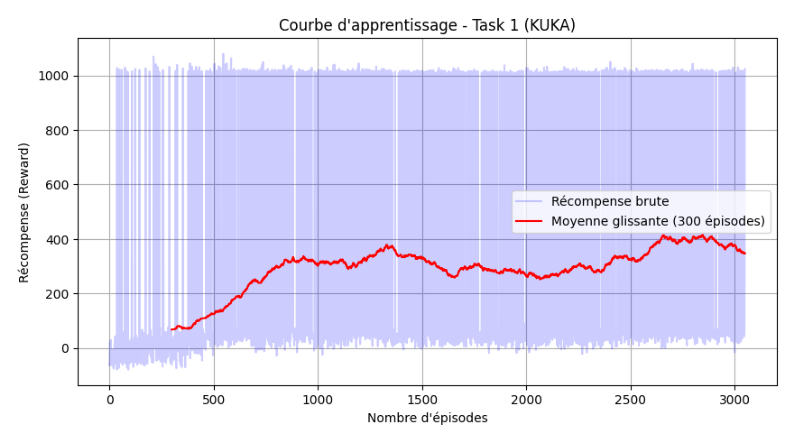

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_1/learning_curve_2.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

Nous avons pu tester de nombreux aux alternatives de reward function pour avoir de meilleurs résultats, mais nous n'avons pas réussi à avoir mieux que celle-ci. Nous avons également essayé de jouer avec d'autres paramètres, comme modifier le nombre de max_step, ou bien de changer isDeterministic en False, mais sans succès.